# Capstone Function 5
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

 Input | Output | Goal |
|-------|--------|------|
| 4D Array (20, 4) | 1D Array (20, ) | Maximise |

## Initial Submission

Bayesian Optimization for 4D chemical process yield optimization (unimodal function).

### Step 1: Import Libraries

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Libraries imported!")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported!


### Step 2: Load Data & Visualize

In [2]:
X_init = np.load('../../data/f5/initial_inputs.npy')
y_init = np.load('../../data/f5/initial_outputs.npy')
print(f"Loaded {X_init.shape[0]} samples, {X_init.shape[1]}D (chemical inputs)")
print(f"Best yield: {y_init.max():.6f}")

Loaded 20 samples, 4D (chemical inputs)
Best yield: 1088.859618


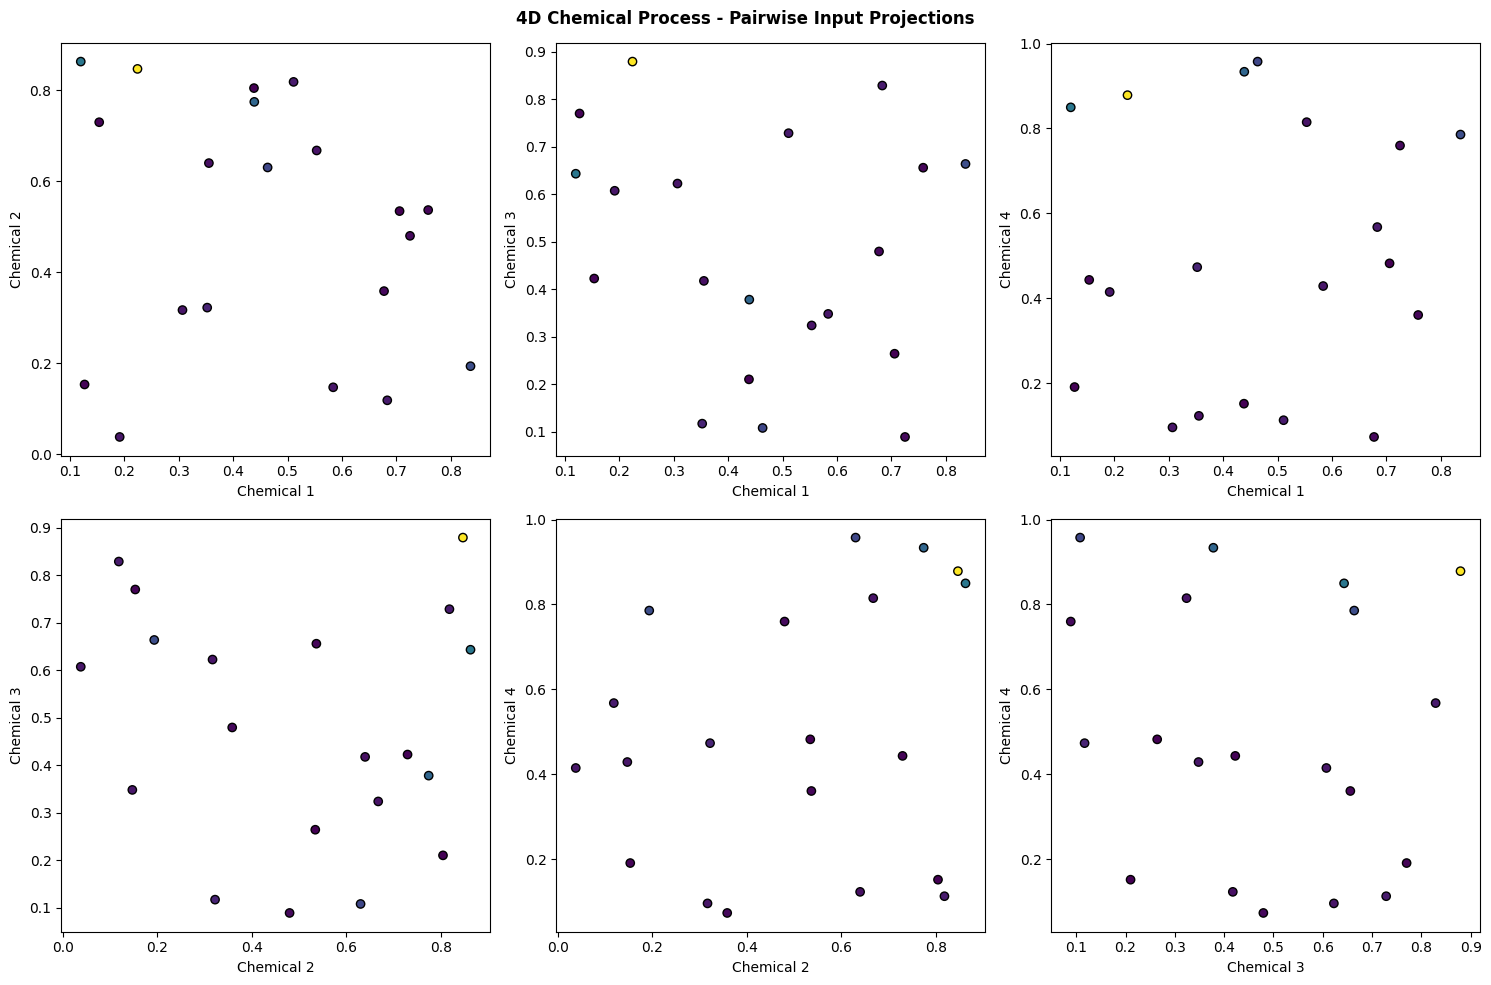

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='viridis', edgecolors='black')
    axes[idx].set_xlabel(f'Chemical {i+1}')
    axes[idx].set_ylabel(f'Chemical {j+1}')
plt.suptitle('4D Chemical Process - Pairwise Input Projections', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters

**4D Chemical Yield (unimodal):**
- GP: Matern 5/2 (smooth response surface)
- Acquisition: Expected Improvement
- Restarts: 15, Raw: 1024 (unimodal allows fewer restarts)

In [ ]:
# All inputs must be in range [0, 0.999999] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [0.999999] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 15, 1024
print(f"Setup complete: {N_DIM}D, bounds [0, 0.999999], {NUM_RESTARTS} restarts")

Setup complete: 4D, 15 restarts


### Step 4: Train GP & Optimize

In [ ]:
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next point: {next_point}")

✓ Next point: [0.15193657 0.96254031 0.97948418 0.93048614]


### Step 5: Visualize Progress

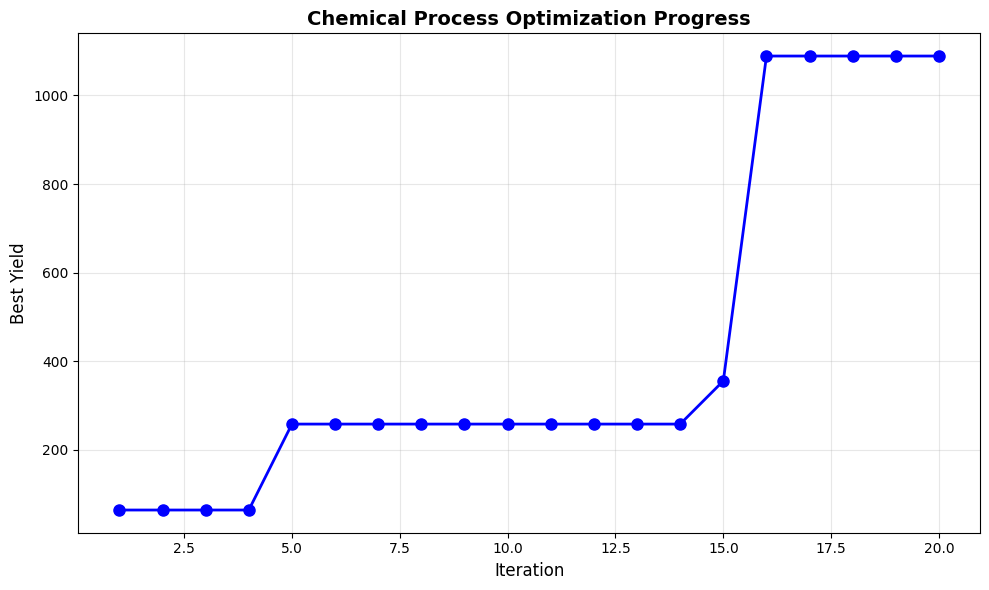

Submission: [0.15193657 0.96254031 0.97948418 0.93048614]


In [6]:
plt.figure(figsize=(10, 6))
best_so_far = np.maximum.accumulate(y_init)
plt.plot(range(1, len(best_so_far)+1), best_so_far, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Yield', fontsize=12)
plt.title('Chemical Process Optimization Progress', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 0.999999, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 6: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 0.999999]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 0.999999]."""
    clamped = [max(0.0, min(0.999999, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(0.999999, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 5")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")